Loading necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Reading Query file and calculating fragment lengths

In [2]:
query_lengths = []
with open('query.bed', 'rt') as f:
    for line in f:
        parts = line.strip().split()
        start = int(parts[1])
        end = int(parts[2])
        fragment_length = end - start
        query_lengths.append(fragment_length)

Calculating frequency distribution for query

In [3]:
query_unique_lengths, query_counts = np.unique(query_lengths, return_counts=True)
query_normalized = query_counts / len(query_lengths)


Reading reference file

In [4]:
reference_data = pd.read_csv('reference.hist', sep='\s+', header=None)
reference_lengths = reference_data[0].values
reference_normalized = reference_data[1].values

Determining fragments to be included from each length of reference

In [5]:
total_rep0_count = 4295020

query_length_to_count = {l: c for l, c in zip(query_unique_lengths, query_counts)}

rep0_lengths = []

for length, prop in zip(reference_lengths, reference_normalized):
    target_count = int(prop * total_rep0_count)
    
    if length in query_length_to_count:
        count_to_include = min(query_length_to_count[length], target_count)
        rep0_lengths.extend([length] * count_to_include)


Calculating frequency distribution for Rep 0

In [6]:
rep0_unique_lengths, rep0_counts = np.unique(rep0_lengths, return_counts=True)
rep0_normalized = rep0_counts / len(rep0_lengths)

Plotting final graph

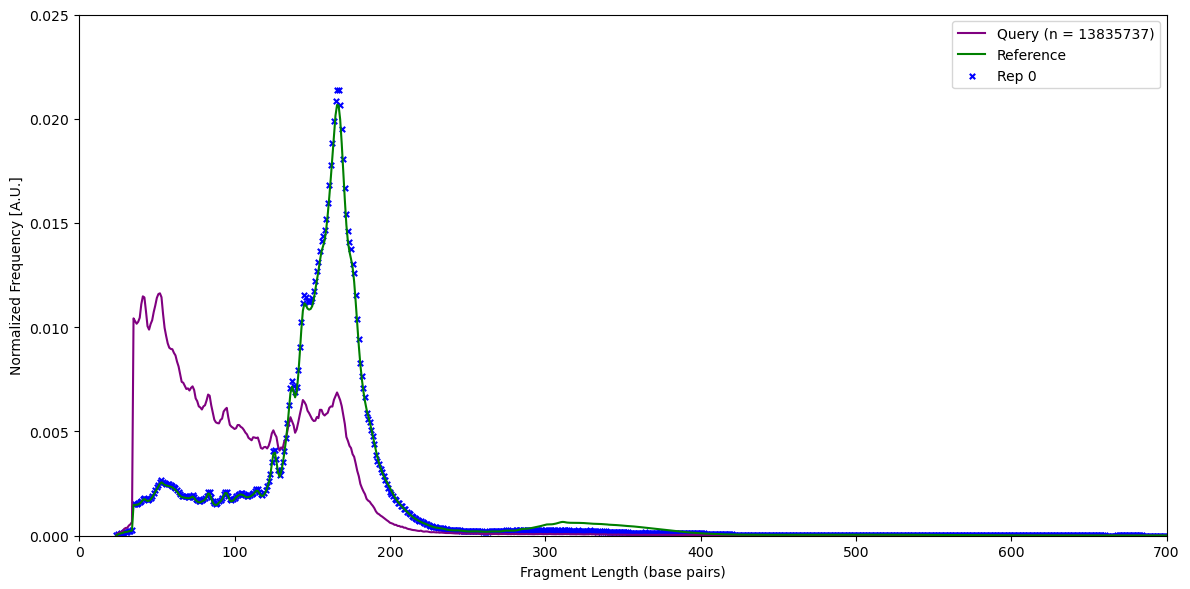

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(query_unique_lengths, query_normalized, color='purple', label=f'Query (n = {len(query_lengths)})')

plt.plot(reference_lengths, reference_normalized, color='green', label='Reference')

plt.scatter(rep0_unique_lengths, rep0_normalized, color='blue', marker='x', s=15, 
           label=f'Rep 0')

plt.xlabel('Fragment Length (base pairs)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.ylim(0, 0.025)
plt.xlim(0, 700)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()